<h1>Range Shifts in Inaturalist Observations</h1>
-species examples: Nene, GALS, Euglandia rosea, More common Honeycreepers, coconut beetle, 
<BR>-average change in altitude 

In [3]:
import pandas as pd
import geopandas as gpd
from shapely import Point
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import traceback
from sklearn.cluster import DBSCAN
import requests
import datetime
import math
general_data = pd.read_csv("CleanedData(valid_est_means+elev).csv")

In [32]:
int = len(general_data.loc[general_data["establishment_means"]=="introduced", "taxon_name"].value_counts())
nat = len(general_data.loc[general_data["establishment_means"]=="native", "taxon_name"].value_counts())
end = len(general_data.loc[general_data["establishment_means"]=="endemic", "taxon_name"].value_counts())

print(int,nat,end)



2430 351 366


Create temp GeoDataframe: Species, date observed, establishment means, latitude, longitude, geometry

In [17]:
general_data["positional_accuracy"] = pd.to_numeric(general_data["positional_accuracy"], errors="coerce")
general_data = general_data.loc[(general_data["positional_accuracy"].notna()) & (general_data["positional_accuracy"] < 1000)]
data = general_data.loc[(general_data["taxon_rank"]=="species")&(general_data["location_obscured"]==False)]

df = pd.DataFrame({"id":data["id"],
                   "taxon_name":data["taxon_name"],
                   "observed_on":data["observed_on"],
                   "establishment_means":data["establishment_means"],
                   "latitude":data["location"].str.split(",").apply(lambda x: x[0]),
                   "longitude":data["location"].str.split(",").apply(lambda x: x[1]),
                   "positional_accuracy":data["positional_accuracy"],
                   })
df["geometry"]=[Point(xy) for xy in zip(df["longitude"],df["latitude"])]

geodf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
#geodf.loc[geodf["observed_on"].str.contains("nan")] = pd.NA


In [ ]:
print(geodf.loc[geodf["taxon_name"]=="Oryctes rhinoceros"])

In [8]:
def plot_Oahu(species, year):
    try:
        geodf1 = geodf.loc[geodf["taxon_name"]== species]
        geodf1 = geodf1.loc[geodf1["observed_on"].str[0:4]==year]
        geodf1.to_crs(epsg=3857)
        landsat = Image.open("Oahu_Landsat_15m.jpg")
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.set_xlim(-158.3233,-157.5988)  # (minx, maxx)
        ax.set_ylim(21.2121,21.7479)
        ax.imshow(landsat, aspect='auto', extent = [-158.3233,-157.5988,21.2121,21.7479])
        geodf1.plot(ax=ax, markersize=4, color="red")
        ax.set_title(f"{species} ({data.loc[data["taxon_name"].str.contains(species), "preferred_common_name"].iloc[0]}) Observations Across Oahu, {year}")
        plt.rcParams['axes.labelcolor'] = '#414141'   # Axis labels
        plt.rcParams['xtick.color'] = '#414141'       # X-axis tick labels
        plt.rcParams['ytick.color'] = '#414141'       # Y-axis tick labels
        plt.rcParams['axes.edgecolor'] = '#414141'    # Axes spines (border)
        plt.rcParams['axes.titlecolor'] = '#414141'   # Title color
        plt.rcParams['figure.facecolor'] = 'white' # Background color (optional)
        plt.rcParams['text.color'] = '#414141'        # Text color
        plt.rcParams['grid.color'] = '#414141' 
        plt.rcParams['font.family']='serif' 
        plt.savefig(f'{species}, {year}.png')
        plt.show()
    except BaseException as e:
        traceback.print_exc()

In [ ]:
for i in range(2011,2025):
    plot_Oahu("Anolis sagrei",str(i))

In [ ]:
geodf1.explore()

<h1>Plotting all islands</h1>

In [20]:
geodf2 = geodf.loc[(geodf["taxon_name"]=="Oryctes rhinoceros")&(geodf["observed_on"].str[0:4]==2024)]
print((geodf["observed_on"].str[0:4]=="2025"))
print(geodf2)

0          True
1          True
2          True
3          True
4          True
          ...  
357630    False
357631    False
357632    False
357633    False
357634    False
Name: observed_on, Length: 357635, dtype: bool
Empty GeoDataFrame
Columns: [taxon_name, observed_on, establishment_means, latitude, longitude, positional_accuracy, geometry]
Index: []


In [6]:
def plot_islands(species, year):
    try:
        geodf2 = geodf.loc[(geodf["taxon_name"]== species)&(geodf["observed_on"].str[0:4]==f"{year}")]

        oahu_lim=[(-158.3233,-157.5988),(21.2121,21.7479)]
        maui_lim=[(-156.736539,-155.944422),(20.464792,21.067242)]
        kauai_lim=[(-160.297467,-159.240847),(21.7501,22.269436)]
        hawaii_lim=[(-156.121764,-154.744125),(18.818758,20.343158)]
        landsat_oahu = Image.open("Landsat Images/Oahu_Landsat_15m.jpg")
        landsat_maui = Image.open("Landsat Images/Maui_Kahoolawe_Landsat_15m.jpg")
        landsat_kauai = Image.open("Landsat Images/Kauai_Niihau_Landsat_15m.jpg")
        landsat_hawaii = Image.open("Landsat Images/Hawaii_Landsat_15m.jpg")

        plt.rcParams['axes.labelcolor'] = '#414141'   # Axis labels
        plt.rcParams['xtick.color'] = '#414141'       # X-axis tick labels
        plt.rcParams['ytick.color'] = '#414141'       # Y-axis tick labels
        plt.rcParams['axes.edgecolor'] = '#414141'    # Axes spines (border)
        plt.rcParams['axes.titlecolor'] = '#414141'   # Title color
        plt.rcParams['figure.facecolor'] = '#faf5ee' # Background color (optional)
        plt.rcParams['text.color'] = '#414141'        # Text color
        plt.rcParams['grid.color'] = '#414141' 
        plt.rcParams['font.family']='serif' 
        
        fig, ax = plt.subplots(2,2,figsize=(10, 8))
        ax[0,1].set_xlim(*(oahu_lim[0]))  # (minx, maxx)
        ax[0,1].set_ylim(*(oahu_lim[1]))
        ax[0,0].set_xlim(*(kauai_lim[0]))  # (minx, maxx)
        ax[0,0].set_ylim(*(kauai_lim[1]))
        ax[1,0].set_xlim(*(maui_lim[0]))  # (minx, maxx)
        ax[1,0].set_ylim(*(maui_lim[1]))
        ax[1,1].set_xlim(*(hawaii_lim[0]))  # (minx, maxx)
        ax[1,1].set_ylim(*(hawaii_lim[1]))
        ax[0,1].imshow(landsat_oahu, aspect='auto', extent = [*(oahu_lim[0]),*(oahu_lim[1])])
        ax[0,0].imshow(landsat_kauai, aspect='auto', extent = [*(kauai_lim[0]),*(kauai_lim[1])])
        ax[1,0].imshow(landsat_maui, aspect='auto', extent = [*(maui_lim[0]),*(maui_lim[1])])
        ax[1,1].imshow(landsat_hawaii, aspect='auto', extent = [*(hawaii_lim[0]),*(hawaii_lim[1])])

        def filter_geodf(geodf, lim):
            return geodf.cx[lim[0][0]:lim[0][1], lim[1][0]:lim[1][1]]
        
        filtered_kauai = filter_geodf(geodf2, kauai_lim)
        filtered_oahu = filter_geodf(geodf2, oahu_lim)
        filtered_maui = filter_geodf(geodf2, maui_lim)
        filtered_hawaii = filter_geodf(geodf2, hawaii_lim)
        
        filtered_kauai.plot(ax=ax[0,0], markersize=4, color="red", aspect="equal")
        filtered_oahu.plot(ax=ax[0,1], markersize=4, color="red", aspect="equal")
        filtered_maui.plot(ax=ax[1,0], markersize=4, color="red", aspect="equal")
        filtered_hawaii.plot(ax=ax[1,1], markersize=4, color="red", aspect="equal")
        fig.suptitle(f"{species} ({data.loc[data["taxon_name"].str.contains(species), "preferred_common_name"].iloc[0]}) Observations Across the Main Hawaiian Islands, {year}")
        ax[0,0].set_title("Kaua'i and Ni'ihau")
        ax[0,1].set_title("O'ahu")
        ax[1,0].set_title("Maui")
        ax[1,1].set_title("Hawai'i")
        

        pos=[-156.6,-156.4,-156.2,-156.0]
        ax[1,0].set_xticks(pos)
        ax[1,0].set_xticklabels([str(i) for i in pos])
        pos=[-156.0,-155.50,-155.0]
        ax[1,1].set_xticks(pos)
        ax[1,1].set_xticklabels([str(i) for i in pos])
        plt.savefig(f'{species}, {year}.png',bbox_inches='tight')
        plt.show()
    except BaseException as e:
        traceback.print_exc()

Elevation is useless. Perhaps analyzing changes between avgs of 1000 random observations from each year. That way the amount of observations is consistent, they are randomized, etc. This will show that there is a trend from actual naturalists to people clustered around low elevation urban areas. Link this to the lorentz curve in the next (user data) section.

In [ ]:
#Plot the observation positions across 2015-2025 for I'Iwi observations whose positional accuracy is <1000 (unobscured)
for i in range(2015,2026):
    plot_islands("Drepanis coccinea",f"{i}")

In [ ]:
#Plot the observation positions across 2020-2024 for Coconut Rhino Beetle observations whose positional accuracy is <1000 (unobscured)
for i in range(2020,2025):
    plot_islands("Oryctes rhinoceros",f"{i}")

<h1>Elevational Trends</h1><br>
O'hia Lehua does NOT favor growth in urban areas, such as perhaps anoles and cats. Thus tourism in urban areas does not bias the data in that way. <br>
<br>
I'Iwi populations are threated by avian malaria, and their location data is generally unobscured on INaturalist. Elevational trends could be visible with enough data.
<br>


IDEA: get a scaling factor for each year (based on multiple tree species - Ohia, Koa, Guava, Eucalyptus, pandanus tectorius) such that avg elevation is constant. Then apply it to birds to see if their elevations are increasing due to malaria


Elevation API loop


In [14]:
from IPython.display import clear_output

elevs = []
selected = data.loc[data["taxon_name"] == "Drepanis coccinea", "location"]
species_data = data.loc[data["taxon_name"] == "Drepanis coccinea"]

for i in range(len(species_data)):
    location = selected.iloc[i]
    longitude = float(location.split(",")[1])
    latitude = float(location.split(",")[0])
    url = f"https://api.open-meteo.com/v1/elevation?latitude={latitude}&longitude={longitude}"
    response = requests.get(url)
    if "403" in response.text:
        break
    elevs.append(response.json()["elevation"][0])
    clear_output(wait=True)
    print(f"{(len(elevs) / len(species_data)) * 100:.1f}%")
    print(response, response.status_code)

100.0%
<Response [200]> 200


save elevations to csv

In [ ]:
#Initialize elevation column to -1
#lis = ['-1.0']*len(data)
#data["elevation"]=lis

#Insert newfound elevation datapoints for specific species
data.loc[data["taxon_name"]=="Drepanis coccinea","elevation"]=elevs
data.to_csv("CleanedData(valid_est_means+elev).csv", index=False)


In [57]:
def plot_avg_annual_elevation(species, cutoff):
    x =[]
    y=[]
    #ADD CONDITION THAT ALLOWS 1 INDIVIDUAL PER 5M RADIUS
    #calculate distance 
    periods = [(year, half) for year in range(2015, 2025) for half in (1, 2)]
    month_ranges = {1: ("01", "02", "03", "04", "05", "06"),
                    2: ("07", "08", "09", "10", "11", "12")}
    
    for year, half in periods:
        months = month_ranges[half]
        mask = (
            (data["taxon_name"] == f"{species}") &
            (data["observed_on"].str[0:4] == str(year)) &
            (data["observed_on"].str[5:7].isin(months)) &
            (data["elevation"].astype(float) >= cutoff) &
            (data["positional_accuracy"] < 250)
        )
        x.append(year + (0.5 if half == 2 else 0))
        y.append((z:=data.loc[mask,"elevation"]).sum()/len(z))
    #x2=np.array(x)
    #y2=np.array(y)
    fig, ax =plt.subplots()
    ax.set_xlim(2015,2025)
    #slope, intercept = np.polyfit(x2,y2,1)
    #y_fit = slope*x2+intercept
    #ax.plot(x2,y_fit, color="red")
    plt.rcParams['axes.labelcolor'] = '#414141'   # Axis labels
    plt.rcParams['xtick.color'] = '#414141'       # X-axis tick labels
    plt.rcParams['ytick.color'] = '#414141'       # Y-axis tick labels
    plt.rcParams['axes.edgecolor'] = '#414141'    # Axes spines (border)
    plt.rcParams['axes.titlecolor'] = '#414141'   # Title color
    plt.rcParams['figure.facecolor'] = 'white' # Background color (optional)
    plt.rcParams['text.color'] = '#414141'        # Text color
    plt.rcParams['grid.color'] = '#414141' 
    plt.rcParams['font.family']='serif'
    ax.plot(x,y, color="blue")
    ax.set_title(f"Elevational trends of {species}, 2015 to 2025", fontsize = 16)
    ax.set_xlabel("Year", fontsize=17)
    ax.set_ylabel("Elevation (m)", fontsize=16)
    ax.set_xmargin(0.01)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor("#FAF5EE")
    fig.set_facecolor("#FAF5EE")
    plt.savefig(f"{species} elevation trends")
    plt.show()

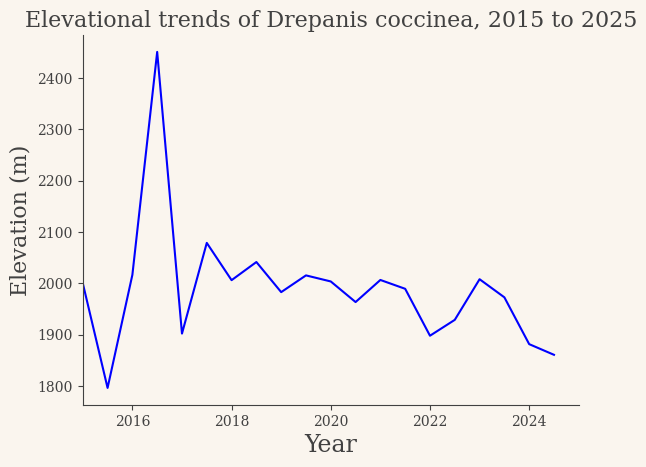

In [58]:
plot_avg_annual_elevation("Drepanis coccinea",10)

Is there really a shift in elevation? I think the increase in tourism (people less likely to hike to higher elevations and document the wildlife) has decreased the average elevation as years progress. At INaturalist's inception, the site was geared more to people who had the means and an interest in documenting wildlife. With the proliferation of smartphones, access has increased and therefore the data has skewed. 

In [11]:
geodf.head()

,taxon_name,observed_on,establishment_means,latitude,longitude,positional_accuracy,geometry
0,Dumortiera hirsuta,2025-02-04,native,19.7214853094,-155.9473904082,737.0,POINT (-155.94739 19.72149)
1,Dimerocostus strobilaceus,2025-02-05,introduced,21.33438,-157.80072,22.0,POINT (-157.80072 21.33438)
2,Angiopteris evecta,2025-02-05,introduced,21.33358,-157.8007366667,193.0,POINT (-157.80074 21.33358)
3,Metrosideros polymorpha,2025-02-05,endemic,19.431055069,-155.2672271729,70.0,POINT (-155.26723 19.43106)
4,Arundina graminifolia,2025-02-05,introduced,19.4304103851,-155.2670898438,70.0,POINT (-155.26709 19.43041)


<h1>What I need to do: </h1>
-print out the list of observations of ohia to find those with location uncertainty under 10m.
<br>
-If any two are within the same 10m radius, delete one.
<br>
-graph the temporal changes of these observations.

In [39]:
geodf.head()

,id,taxon_name,observed_on,establishment_means,latitude,longitude,positional_accuracy,geometry
0,260757382,Dumortiera hirsuta,2025-02-04,native,19.7214853094,-155.9473904082,737.0,POINT (-155.94739 19.72149)
1,260756800,Dimerocostus strobilaceus,2025-02-05,introduced,21.33438,-157.80072,22.0,POINT (-157.80072 21.33438)
2,260756739,Angiopteris evecta,2025-02-05,introduced,21.33358,-157.8007366667,193.0,POINT (-157.80074 21.33358)
3,260756451,Metrosideros polymorpha,2025-02-05,endemic,19.431055069,-155.2672271729,70.0,POINT (-155.26723 19.43106)
4,260756362,Arundina graminifolia,2025-02-05,introduced,19.4304103851,-155.2670898438,70.0,POINT (-155.26709 19.43041)


Fix this it doesnt work!

In [ ]:
def distance(x,y,xx,yy):
    return math.sqrt(math.pow((float(xx)-float(x)),2)+math.pow((float(yy)-float(y)),2))

geodf1 = geodf.loc[(geodf["positional_accuracy"]<11) & (geodf["taxon_name"].str.contains("Metrosideros polymorpha"))]

#loop through the dataset. For each data point, compare distance to all other datapoints and remove those <11 m away.
for observation in geodf1.itertuples():
    for subobservation in geodf1.itertuples():
        if observation.id==subobservation.id:
            continue
        if distance(observation.latitude,observation.longitude,subobservation.latitude,subobservation.longitude)<11:
            geodf1.drop(index=(geodf1.loc[geodf1["id"]==subobservation.id]).index) 


<h2>Obtaining elevations for random entries, 10000 of them and see what trends they have.</h2>

<h1>Tracking Phenological Changes Among Migratory Species</h1>
tracking other phenological changes in species requries image processing, which I will not be doing. Migration cycles are the easiest to see with basic data.

Pluvialis fulva



In [ ]:
def plot_migration(species, since, until):
    months=["January","February","March","April","May","June","July","August","September","October","November","December"]
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(f"Migratory pattern of {species}, {since} to {until - 1}", fontsize = 16)
    ax.set_xlabel("Day of the year", fontsize=17)
    ax.set_ylabel("Number of Observations", fontsize=16)
    ax.set_xmargin(0.01)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor("#FAF5EE")
    fig.set_facecolor("#FAF5EE")
    ax.tick_params(axis='x', labelsize=12)

    geodf1 = geodf.loc[(geodf["observed_on"].notna())&(geodf["taxon_name"]==species)].copy()
#observed_on to datetime object
    geodf1["observed_on"] = pd.to_datetime(geodf1["observed_on"],format="%Y-%m-%d") #observed_on to datetime object

    # Cycle through the years
    for year in range(since,until):
#observed_on datetime object to day of the year
        series_iter = geodf1.loc[geodf1["observed_on"].dt.year==year,"observed_on"].map(lambda x: (x-datetime.datetime(x.year,1,1)).days + 1)
    #y=value counts for day of the year
        y = series_iter.value_counts().sort_index()
        rt = list(zip(y.values,y.index.values))
        if year%4==0: #leapyear
            if y.index.values[-1]==365:
                for i in range(0,365):
                    if(rt[i][1]!=i+1):
                        rt.insert(i,(0,i+1))
                try:
                    rt.insert(59,((rt[58][0]+rt[60][0])//2, 60)) #add in the 60th day of the year as the average of the 27th of feb and 1st of march
                except:
                    try:
                        rt.insert(59,(rt[60][0]), 60) #add in the 60th day of the year as the 61st day
                    except:
                        rt.insert(59,(rt[58][0]), 60) #add in the 60th day of the year as the 59th day
            else:
                for i in range(0,366):
                    if(rt[i][1]!=i+1):
                        rt.insert(i,(0,i+1))     
        else: #non-leapyear
            for i in range(0,365):
                #if the day of the year doesnt match the iterator day of the year, insert a 0 on that day
                try:
                    if(rt[i][1]!=i+1):
                        rt.insert(i,(0,i+1))
                except:
                    rt.insert(i,(0,i+1))
            try:
                rt.insert(59,((rt[58][0]+rt[60][0])//2, 60)) #add in the 60th day of the year as the average of the 27th of feb and 1st of march
            except:
                try:
                    rt.insert(59,(rt[60][0]), 60) #add in the 60th day of the year as the 61st day
                except:
                    rt.insert(59,(rt[58][0]), 60) #add in the 60th day of the year as the 59th day

        a,b = zip(*rt)
        a=list(a)
        #to even out the noise through a somewhat rolling average
        for i in range(len(a)//6):
            val = (a[6*i]+a[6*i+1]+a[6*i+2]+a[6*i+3]+a[6*i+4]+a[6*i+5])
            a[6*i] = val
            a[6*i+1] = val
            a[6*i+2] = val
            a[6*i+3] = val
            a[6*i+4] = val
            a[6*i+5] = val
        #rolling window average with padding (circular rolling average)
        a = a[366-14:367] + a + a[0:15]
        adf = pd.Series(a).rolling(window = 30, center=True).mean() 
        adf = adf.iloc[15:381]
        adf = adf.reset_index(drop=True)
        plt.plot(adf.values, label=year)
        plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{species}_Phenology.png")
    plt.show()

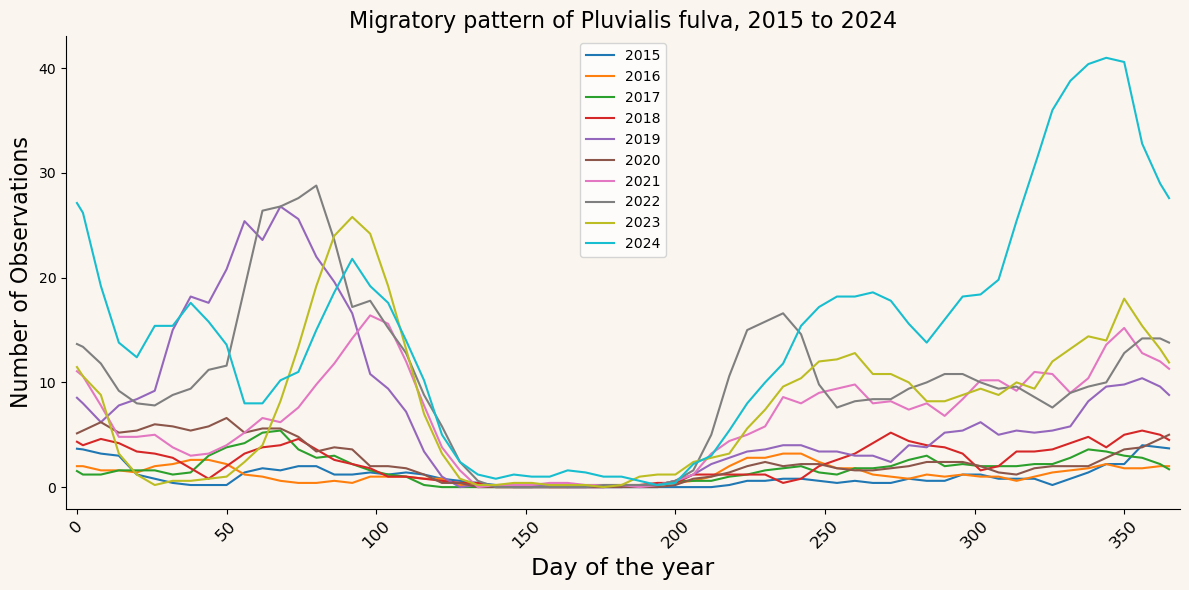

In [89]:
plot_migration("Pluvialis fulva", 2015,2025)

<h3>Using DBSCAN to find groupings of species on islands</h3>

In [240]:
def plot_DB(min_samples, species = "Metrosideros polymorpha", year="2024", island="Oahu", month="01"):
    geodf1 = geodf.loc[geodf["taxon_name"].str.contains(species)]
    yrs=[]
    for i in range(2008,2025):
        yrs.append(f"{i}")
    geodf1 = geodf1.loc[
        (geodf1["observed_on"].notna()) &
        (geodf1["observed_on"].str[:4].str.contains("|".join(yrs))) & 
        (geodf1["observed_on"].str[-2:].str.contains(month))] 
    xmax=-157.5988
    xmin=-158.3233
    ymax=21.7479
    ymin=21.2121
    geodf1 = geodf1[(geodf1.geometry.x>=xmin)&(geodf1.geometry.x<=xmax)&(geodf1.geometry.y>=ymin)&(geodf1.geometry.y<=ymax)]   
    data = list(zip(
        x:=geodf1.geometry.x,
        y:=geodf1.geometry.y
        ))
    
    ##k=min_samples
    #distances=[]
    #for i in range(len(geodf1)):
    #    eucl_dist=[]
    #    for j in range(len(geodf1)): 
    #        if(i!=j):
    #            eucl_dist.append((
    #                (geodf1.geometry.x.iloc[j]-geodf1.geometry.x.iloc[i])**(2)+
    #                (geodf1.geometry.y.iloc[j]-geodf1.geometry.y.iloc[i])**(2)
    #                )**(1/2))
    #    eucl_dist.sort()
    #    distances.append(eucl_dist[k])
    #plt.hist(distances)

    model = DBSCAN(eps = 0.018, min_samples = min_samples)
    cluster = model.fit(data)
    labels = cluster.labels_

    #K distance graph


    #DBSCAN GRAPH
    fig, ax = plt.subplots()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    geodf1.to_crs(epsg=3857)
    landsat = Image.open("Oahu_Landsat_15m.jpg")
    ax.set_xlim(-158.3233,-157.5988)  # (minx, maxx)
    ax.set_ylim(21.2121,21.7479)
    ax.imshow(landsat, aspect='auto', extent = [-158.3233,-157.5988,21.2121,21.7479])
    ax.set_title(f"{species} DBSCAN, {year},{island}")
    scatter1 = plt.scatter(x,y, c = labels, cmap = "inferno", marker = '.', s=5)
    cbar = plt.colorbar(scatter1)
    plt.show()

    #get the data from the dataset based on parameters
    #define the DBSCAN model
    #plot the DBSCAN findings
 

#PLOT ALL YEARS 2008-2024, BUT ONLY BY MONTH. SEE HOW THE DISTRIBUTION CHANGES MONTHLY TO BOLSTER CLAIM OF TOURISM BIAS

In [ ]:
for i in range(1,13):
    if len(str(i))==1:
        plot_DB(5,month=f'0{i}')
    elif len(str(i))==2:
        plot_DB(5,month=f'{i}')